In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
import numpy as np

In [3]:
# This file contains a series of financial and macroeconomic outcome variables.
macro = pd.read_csv("../data3/macro.csv", index_col=0)

mret = macro[['indprol1']]
mret.tail()
# mret.plot()

,indprol1
date,
2020-08-01,-0.000456
2020-09-01,0.006083
2020-10-01,0.004420
2020-11-01,0.011487
2020-12-01,0.008215


In [4]:
# This file contains labeled attention to topics from structureofnews.com

topics = pd.read_csv("../data3/topics.csv", index_col=0)
topics.tail()

,Natural disasters,Internet,Soft drinks,Mobile devices,Profits,M&A,Changes,Police/crime,Research,Executive pay,...,European politics,Size,NASD,Mexico,Retail,Long/short term,Wide range,Lawsuits,UK,Revenue growth
date,,,,,,,,,,,,,,,,,,,,,
2017-02-01,0.005041,0.010796,0.004336,0.009094,0.004619,0.003726,0.006224,0.011012,0.006346,0.004761,...,0.011896,0.005128,0.003284,0.007718,0.004835,0.005311,0.004215,0.005482,0.003075,0.006990
2017-03-01,0.006498,0.011357,0.003211,0.007999,0.003005,0.003417,0.006758,0.011267,0.005931,0.004582,...,0.014791,0.005581,0.002946,0.004698,0.005293,0.005542,0.004170,0.004596,0.004484,0.005598
2017-04-01,0.006052,0.010458,0.003448,0.007871,0.004473,0.003301,0.006595,0.010880,0.006122,0.004075,...,0.020162,0.006293,0.003023,0.004557,0.005231,0.004725,0.004145,0.005918,0.002775,0.005881
2017-05-01,0.005192,0.009293,0.003597,0.007684,0.003389,0.003350,0.006191,0.012366,0.006202,0.003481,...,0.013386,0.005571,0.002984,0.004510,0.006182,0.005368,0.004217,0.004596,0.003356,0.005258
2017-06-01,0.006807,0.012327,0.002527,0.009575,0.001858,0.004042,0.006155,0.013799,0.004839,0.003334,...,0.016046,0.005707,0.003476,0.004613,0.007563,0.005004,0.004559,0.004741,0.004814,0.005598


In [5]:
# Restrict both datasets to overlapping dates
common_dates = macro.index.intersection(topics.index)

macro = macro.loc[common_dates]
topics = topics.loc[common_dates]

print(f"Overlapping period: {common_dates[0]} → {common_dates[-1]}  ({len(common_dates)} months)")

Overlapping period: 1984-01-01 → 2017-06-01  (402 months)


In [6]:
articles = pd.read_parquet("../data3/articles.pq")
articles.head()

,accession_number,display_date,headline
0,19840102000129,1984-01-02 07:00:00,Portfolio Managers See Overseas Stocks Climbin...
1,19840117000049,1984-01-17 07:00:00,Four Big Banks Had Profit Gains In 4th Period ...
2,19840117000136,1984-01-17 07:00:00,World Brief: U.S. and Common Market Sign Accor...
3,19840117000164,1984-01-17 07:00:00,Speaking of Business: Consumers May Be Becomin...
4,19840123000136,1984-01-23 07:00:00,Dollar Moves Up On Rise in GNP; Gold Weakens -...


---
# 3.a

In [ ]:
import numpy as np
from tqdm import tqdm
from openai import OpenAI
import pandas as pd

#------------------------------------------------------------------------------
# Login into API
#------------------------------------------------------------------------------

key = "MY KEY INSERT HERE"
client = OpenAI(api_key = key)
print('API Connected!')

#------------------------------------------------------------------------------
# This function converts text to embeddings and adds the embedding vector as 
# an addtional vector to your df. You can input the preferred dimension. 
#------------------------------------------------------------------------------

def get_batch_embeddings(texts, model="text-embedding-3-small", dimensions=250, batch_size=100):
    embeddings = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding batches"):
        batch = texts[i:i+batch_size]
        response = client.embeddings.create(
            input=batch,
            model=model,
            dimensions=dimensions
        )
        batch_embeddings = [res.embedding for res in response.data]
        embeddings.extend(batch_embeddings)
    return embeddings

#------------------------------------------------------------------------------

file_path = "../data3/articles.pq"
df_articles = pd.read_parquet(file_path)

text = df_articles['headline'].tolist()

df_articles['ada_embedding'] = get_batch_embeddings(text, dimensions=250)

#------------------------------------------------------------------------------

API Connected!


Embedding batches: 100%|██████████| 102/102 [01:03<00:00,  1.60it/s]


In [11]:
df_articles

,accession_number,display_date,headline,ada_embedding
0,19840102000129,1984-01-02 07:00:00.000,Portfolio Managers See Overseas Stocks Climbin...,"[0.04220981150865555, 0.011265545152127743, 0...."
1,19840117000049,1984-01-17 07:00:00.000,Four Big Banks Had Profit Gains In 4th Period ...,"[0.003069576108828187, -0.0651627629995346, 0...."
2,19840117000136,1984-01-17 07:00:00.000,World Brief: U.S. and Common Market Sign Accor...,"[0.00654153386130929, -0.014524983242154121, 0..."
3,19840117000164,1984-01-17 07:00:00.000,Speaking of Business: Consumers May Be Becomin...,"[0.1106259673833847, -0.05225652456283569, 0.0..."
4,19840123000136,1984-01-23 07:00:00.000,Dollar Moves Up On Rise in GNP; Gold Weakens -...,"[0.009533146396279335, 0.04138055071234703, 0...."
...,...,...,...,...
10195,20171215000061,2017-12-15 07:09:51.328,World News: As Beijing Courts Neighbors New Im...,"[0.09702882170677185, 0.06539630144834518, 0.1..."
10196,20171208000021,2017-12-08 07:03:11.788,Banking & Finance: Chinese Insurer Ping An Bec...,"[-0.01812531054019928, -0.09764700382947922, 0..."
10197,20171227000047,2017-12-27 07:05:31.859,U.S. News: Cities Sue Pentagon in Effort to Cu...,"[0.05128667876124382, 0.060955267399549484, 0...."
10198,20171221000030,2017-12-21 07:04:41.822,Credit Markets: Treasury Yields Are on a Roll ...,"[-0.00036020332481712103, 0.05535576120018959,..."


In [ ]:
# df_articles.to_parquet("../data3/articles_with_embeddings.pq")

# df_articles = pd.read_parquet("../data3/articles_with_embeddings.pq")

# df_articles

,accession_number,display_date,headline,ada_embedding
0,19840102000129,1984-01-02 07:00:00.000,Portfolio Managers See Overseas Stocks Climbin...,"[0.04220981150865555, 0.011265545152127743, 0...."
1,19840117000049,1984-01-17 07:00:00.000,Four Big Banks Had Profit Gains In 4th Period ...,"[0.003069576108828187, -0.0651627629995346, 0...."
2,19840117000136,1984-01-17 07:00:00.000,World Brief: U.S. and Common Market Sign Accor...,"[0.00654153386130929, -0.014524983242154121, 0..."
3,19840117000164,1984-01-17 07:00:00.000,Speaking of Business: Consumers May Be Becomin...,"[0.1106259673833847, -0.05225652456283569, 0.0..."
4,19840123000136,1984-01-23 07:00:00.000,Dollar Moves Up On Rise in GNP; Gold Weakens -...,"[0.009533146396279335, 0.04138055071234703, 0...."
...,...,...,...,...
10195,20171215000061,2017-12-15 07:09:51.328,World News: As Beijing Courts Neighbors New Im...,"[0.09702882170677185, 0.06539630144834518, 0.1..."
10196,20171208000021,2017-12-08 07:03:11.788,Banking & Finance: Chinese Insurer Ping An Bec...,"[-0.01812531054019928, -0.09764700382947922, 0..."
10197,20171227000047,2017-12-27 07:05:31.859,U.S. News: Cities Sue Pentagon in Effort to Cu...,"[0.05128667876124382, 0.060955267399549484, 0...."
10198,20171221000030,2017-12-21 07:04:41.822,Credit Markets: Treasury Yields Are on a Roll ...,"[-0.00036020332481712103, 0.05535576120018959,..."


Monthly embeddings: 402 months × 250 dimensions

--- Part 1.a repeat (mret) ---
α = 0.004649 → selected dims: ['emb_24', 'emb_48', 'emb_68', 'emb_123', 'emb_229']
Embeddings OLS R² = 0.0480  (Topics R² = 0.1079)

--- Part 1.b repeat (all targets) ---
    (no exact 5; using 4 non-zero instead)
    (no exact 5; using 4 non-zero instead)
    (no exact 5; using 4 non-zero instead)
    (no exact 5; using 4 non-zero instead)
    (no exact 5; using 4 non-zero instead)
    (no exact 5; using 4 non-zero instead)
    (no exact 5; using 4 non-zero instead)
    (no exact 5; using 4 non-zero instead)
    (no exact 5; using 4 non-zero instead)
    (no exact 5; using 4 non-zero instead)

           Embeddings R²  Topics R²  Difference
vol               0.2735     0.6294     -0.3559
indprol1          0.1136     0.2767     -0.1631
indpro            0.1016     0.2191     -0.1175
mret              0.0480     0.1079     -0.0599
Aero_vol          0.1564        NaN         NaN
Agric_vol         0.1436      

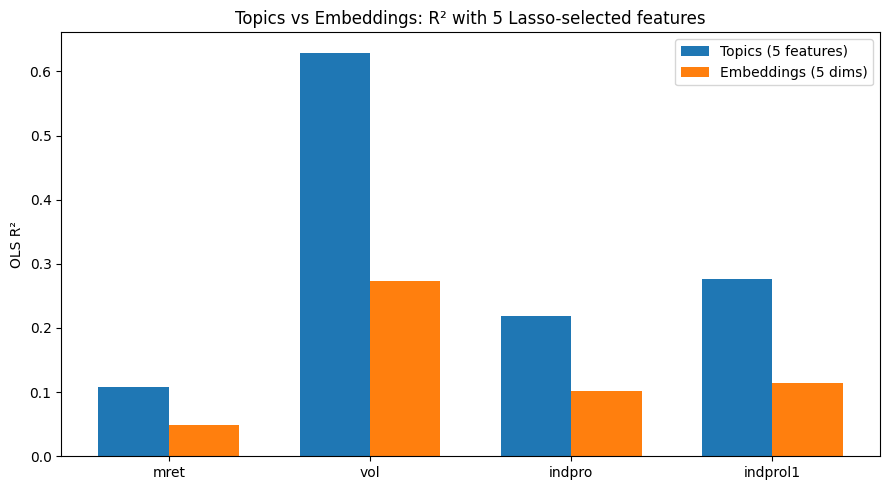

In [9]:
import warnings
from sklearn.linear_model import lasso_path
warnings.filterwarnings("ignore", message=".*Objective did not converge.*")

# ── Aggregate embeddings to monthly means ──
emb_matrix = np.vstack(df_articles["ada_embedding"].values)  # (10200, 250)
emb_df = pd.DataFrame(emb_matrix, index=df_articles["display_date"].dt.to_period("M").dt.to_timestamp().dt.strftime("%Y-%m-%d"))
emb_df.columns = [f"emb_{i}" for i in range(emb_matrix.shape[1])]
monthly_emb = emb_df.groupby(level=0).mean()

# Align with macro
common_emb = macro.index.intersection(monthly_emb.index)
macro_emb = macro.loc[common_emb]
emb_al = monthly_emb.loc[common_emb]
print(f"Monthly embeddings: {emb_al.shape[0]} months × {emb_al.shape[1]} dimensions")

# ── Helper: find α closest to 5 non-zero coefficients ──
def lasso_select_5(X_sc, y, alphas, feature_names):
    """Run lasso_path and find the best α for ~5 non-zero coefficients."""
    alphas_path, coef_path, _ = lasso_path(X_sc, y, alphas=alphas, max_iter=100_000)
    n_nz = (coef_path != 0).sum(axis=0)

    # Try exact 5 first, then closest
    mask_5 = n_nz == 5
    if mask_5.any():
        idx = np.where(mask_5)[0][0]
    else:
        idx = np.argmin(np.abs(n_nz - 5))
        print(f"    (no exact 5; using {n_nz[idx]} non-zero instead)")

    coefs = coef_path[:, idx]
    sel = feature_names[coefs != 0].tolist()
    return alphas_path[idx], sel, alphas_path, coef_path, n_nz

# ── Reference R² from topics (part 1.a/1.b) ──
topic_r2_ref = {"mret": 0.1079, "vol": 0.6294, "indpro": 0.2191, "indprol1": 0.2767}
alphas_grid = np.logspace(-6, 0, 500)  # finer grid to hit 5 more often

# ── Part 1.a repeat: mret with ~5 embedding features ──
TARGET = "mret"
y = macro_emb[TARGET].dropna()
X_e = emb_al.loc[y.index]
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_e)

alpha_5, selected, _, _, _ = lasso_select_5(X_sc, y, alphas_grid, emb_al.columns)
X_ols = sm.add_constant(X_e[selected])
ols = sm.OLS(y, X_ols).fit()
print(f"\n--- Part 1.a repeat (mret) ---")
print(f"α = {alpha_5:.6f} → selected dims: {selected}")
print(f"Embeddings OLS R² = {ols.rsquared:.4f}  (Topics R² = {topic_r2_ref['mret']:.4f})")

# ── Part 1.b repeat: all targets with ~5 embedding features ──
print(f"\n--- Part 1.b repeat (all targets) ---")
vol_cols = [c for c in macro_emb.columns if c.endswith("_vol")]
TARGETs = ["mret", "vol", "indpro", "indprol1"] + vol_cols

results_emb = {}
for TARGET in TARGETs:
    y = macro_emb[TARGET].dropna()
    X_e = emb_al.loc[y.index]
    scaler = StandardScaler()
    X_sc = scaler.fit_transform(X_e)

    a5, sel, _, _, _ = lasso_select_5(X_sc, y, alphas_grid, emb_al.columns)
    if len(sel) == 0:
        print(f"  {TARGET}: no features selected, skipping.")
        continue

    X_ols = sm.add_constant(X_e[sel])
    r2 = sm.OLS(y, X_ols).fit().rsquared
    results_emb[TARGET] = r2

# ── Summary comparison table ──
compare = pd.DataFrame({
    "Embeddings R²": pd.Series(results_emb),
    "Topics R²": pd.Series(topic_r2_ref)
}).dropna(how="all")
compare["Difference"] = compare["Embeddings R²"] - compare["Topics R²"]
compare = compare.sort_values("Topics R²", ascending=False)

print(f"\n{'='*55}")
print(compare.to_string(float_format=lambda x: f"{x:.4f}"))

# ── Bar chart: embeddings vs topics for key targets ──
key_targets = [t for t in ["mret", "vol", "indpro", "indprol1"] if t in compare.index]
comp_key = compare.loc[key_targets]

x = np.arange(len(comp_key))
width = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(x - width/2, comp_key["Topics R²"], width, label="Topics (5 features)")
ax.bar(x + width/2, comp_key["Embeddings R²"], width, label="Embeddings (5 dims)")
ax.set_xticks(x)
ax.set_xticklabels(comp_key.index)
ax.set_ylabel("OLS R²")
ax.set_title("Topics vs Embeddings: R² with 5 Lasso-selected features")
ax.legend()
plt.tight_layout()
plt.show()

-----
# 3.b

Can we recover curated topics from embeddings?

Topic                       Ridge R²    Adj. R²
------------------------------------------------
Recession                     0.6672     0.1162
Oil market                    0.4732    -0.3991
Financial crisis              0.8004     0.4700
Options/VIX                   0.4979    -0.3333


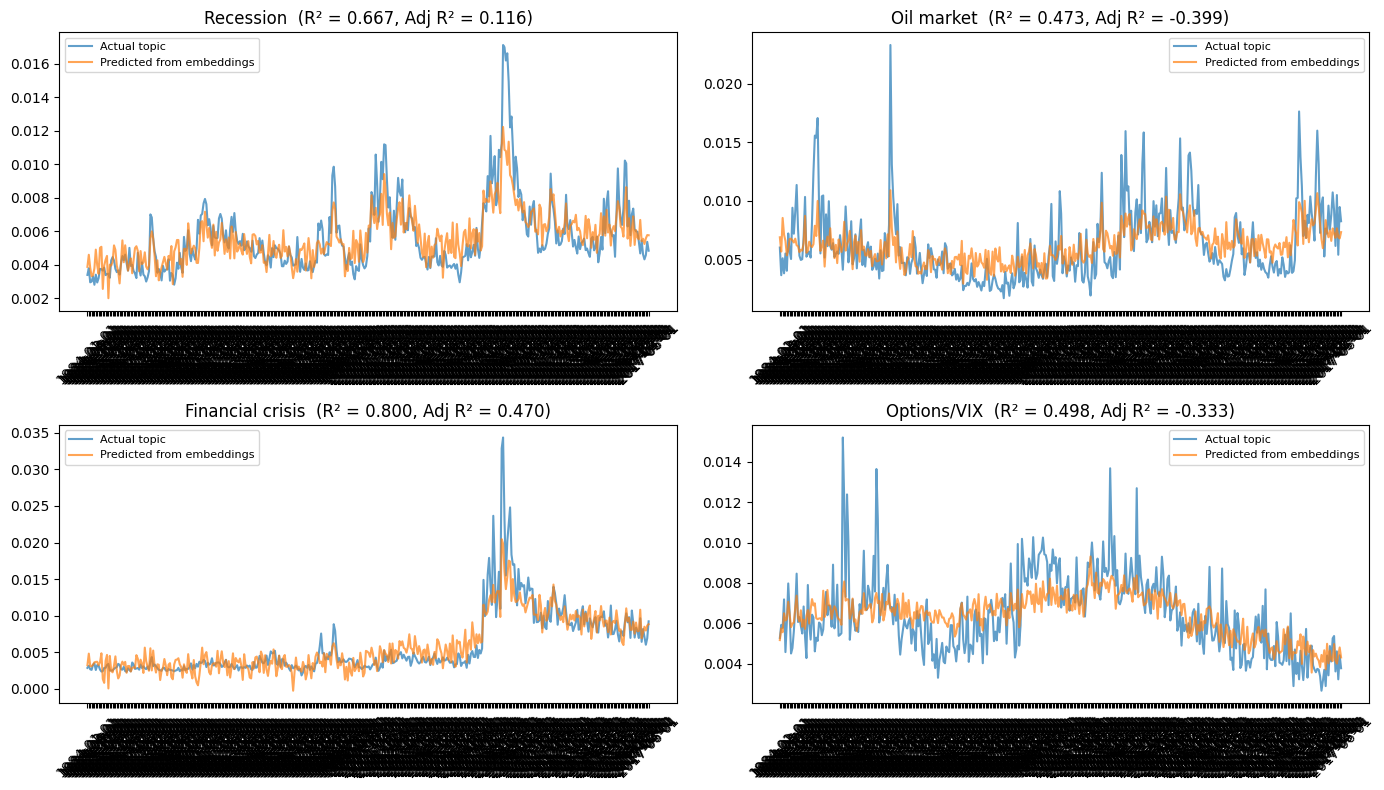

In [15]:
from sklearn.linear_model import RidgeCV

# ── Pick representative topics (important ones from parts 1.a/1.b) ──
selected_topics = ["Recession", "Oil market", "Financial crisis", "Options/VIX"]

# Align topics with embeddings on common dates
common_te = topics.index.intersection(emb_al.index)
topics_al = topics.loc[common_te]
emb_al_t = emb_al.loc[common_te]

scaler = StandardScaler()
X_emb_sc = scaler.fit_transform(emb_al_t)

print("Can we recover curated topics from embeddings?\n")
print(f"{'Topic':<25} {'Ridge R²':>10} {'Adj. R²':>10}")
print("-" * 48)

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.ravel()

for i, topic in enumerate(selected_topics):
    y_topic = topics_al[topic]

    # RidgeCV: use all 250 embedding dims to predict the topic
    ridge = RidgeCV(alphas=np.logspace(-3, 5, 100)).fit(X_emb_sc, y_topic)
    y_pred = ridge.predict(X_emb_sc)
    
    ss_res = np.sum((y_topic - y_pred) ** 2)
    ss_tot = np.sum((y_topic - y_topic.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    n, p = X_emb_sc.shape
    adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

    print(f"{topic:<25} {r2:>10.4f} {adj_r2:>10.4f}")

    # Plot actual vs predicted
    axes[i].plot(common_te, y_topic.values, alpha=0.7, label="Actual topic")
    axes[i].plot(common_te, y_pred, alpha=0.7, label="Predicted from embeddings")
    axes[i].set_title(f"{topic}  (R² = {r2:.3f}, Adj R² = {adj_r2:.3f})")
    axes[i].legend(fontsize=8)
    axes[i].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

Recession and Financial crisis are clearly recoverable, evident by the high R^2 adj. Easy to tell that is has been encoded clearly.

----
# 3.c

----
# 3.d

Running embeddings + Ridge forecast...
Running embeddings + Lasso forecast...
Running topics + Lasso forecast...

OOS R² — Embeddings (Ridge):  0.0337
OOS R² — Embeddings (Lasso):  0.0116
OOS R² — Topics (Lasso):      0.1410


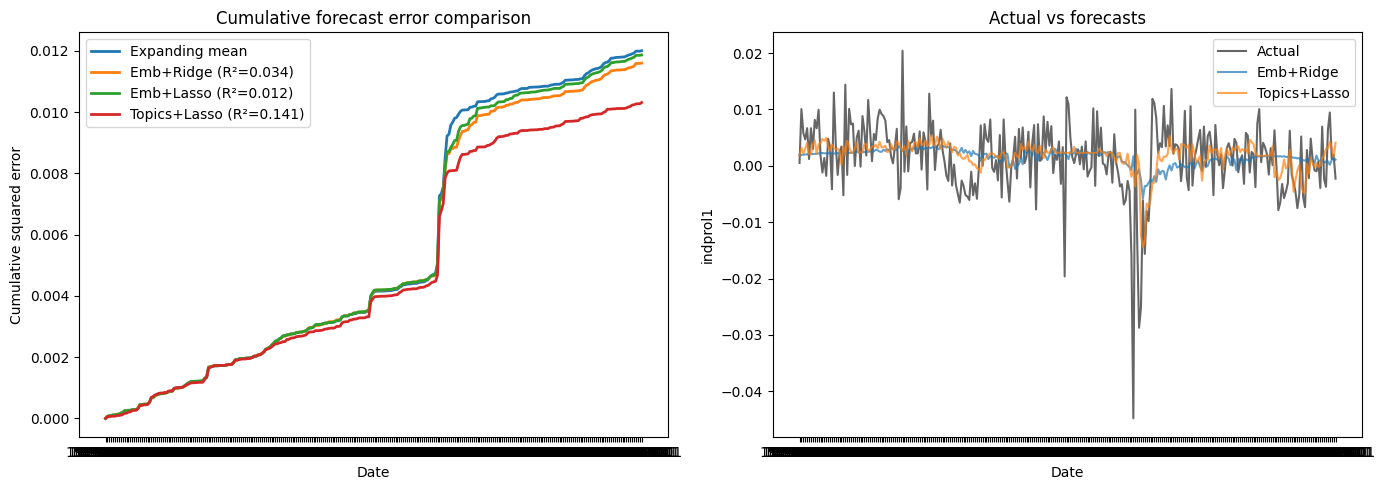

In [16]:
from sklearn.linear_model import RidgeCV, LassoCV
from sklearn.model_selection import TimeSeriesSplit

TARGET = "indprol1"

# ── Prepare embeddings ──
y_e = macro_emb[TARGET].dropna().values
X_e = emb_al.loc[macro_emb[TARGET].dropna().index].values
dates_e = macro_emb[TARGET].dropna().index

# ── Also prepare topics for comparison (same date range) ──
common_t = topics.index.intersection(macro_emb[TARGET].dropna().index)
y_t = macro.loc[common_t, TARGET].values
X_t = topics.loc[common_t].values
dates_t = common_t

MIN_TRAIN = 120
tscv = TimeSeriesSplit(n_splits=5)

def expanding_ridge_forecast(X_raw, y, n_train):
    """Expanding-window RidgeCV forecast."""
    n = len(y)
    scaler = StandardScaler().fit(X_raw)
    X_sc = scaler.transform(X_raw)
    preds = np.full(n, np.nan)
    for t in range(n_train, n):
        model = RidgeCV(alphas=np.logspace(-2, 5, 50), cv=tscv)
        model.fit(X_sc[:t], y[:t])
        preds[t] = model.predict(X_sc[[t]])[0]
    return preds[n_train:]

def expanding_lasso_forecast(X_raw, y, n_train):
    """Expanding-window LassoCV forecast."""
    n = len(y)
    scaler = StandardScaler().fit(X_raw)
    X_sc = scaler.transform(X_raw)
    preds = np.full(n, np.nan)
    for t in range(n_train, n):
        model = LassoCV(cv=tscv, alphas=50, max_iter=20_000)
        model.fit(X_sc[:t], y[:t])
        preds[t] = model.predict(X_sc[[t]])[0]
    return preds[n_train:]

def oos_r2(actuals, preds, y_full, n_train):
    exp_mean = np.array([y_full[:t].mean() for t in range(n_train, len(y_full))])
    return 1 - np.sum((actuals - preds)**2) / np.sum((actuals - exp_mean)**2)

# ── Run forecasts ──
print("Running embeddings + Ridge forecast...")
preds_emb_ridge = expanding_ridge_forecast(X_e, y_e, MIN_TRAIN)
r2_emb_ridge = oos_r2(y_e[MIN_TRAIN:], preds_emb_ridge, y_e, MIN_TRAIN)

print("Running embeddings + Lasso forecast...")
preds_emb_lasso = expanding_lasso_forecast(X_e, y_e, MIN_TRAIN)
r2_emb_lasso = oos_r2(y_e[MIN_TRAIN:], preds_emb_lasso, y_e, MIN_TRAIN)

print("Running topics + Lasso forecast...")
preds_top = expanding_lasso_forecast(X_t, y_t, MIN_TRAIN)
r2_top = oos_r2(y_t[MIN_TRAIN:], preds_top, y_t, MIN_TRAIN)

print(f"\nOOS R² — Embeddings (Ridge):  {r2_emb_ridge:.4f}")
print(f"OOS R² — Embeddings (Lasso):  {r2_emb_lasso:.4f}")
print(f"OOS R² — Topics (Lasso):      {r2_top:.4f}")

# ── Plot ──
actuals_e = y_e[MIN_TRAIN:]
exp_mean_e = np.array([y_e[:t].mean() for t in range(MIN_TRAIN, len(y_e))])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cum_bench = np.cumsum((actuals_e - exp_mean_e)**2)
cum_emb_r = np.cumsum((actuals_e - preds_emb_ridge)**2)
cum_emb_l = np.cumsum((actuals_e - preds_emb_lasso)**2)
cum_top = np.cumsum((y_t[MIN_TRAIN:] - preds_top)**2)

axes[0].plot(dates_e[MIN_TRAIN:], cum_bench, label="Expanding mean", linewidth=2)
axes[0].plot(dates_e[MIN_TRAIN:], cum_emb_r, label=f"Emb+Ridge (R²={r2_emb_ridge:.3f})", linewidth=2)
axes[0].plot(dates_e[MIN_TRAIN:], cum_emb_l, label=f"Emb+Lasso (R²={r2_emb_lasso:.3f})", linewidth=2)
axes[0].plot(dates_t[MIN_TRAIN:], cum_top, label=f"Topics+Lasso (R²={r2_top:.3f})", linewidth=2)
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Cumulative squared error")
axes[0].set_title("Cumulative forecast error comparison")
axes[0].legend()

axes[1].plot(dates_e[MIN_TRAIN:], actuals_e, label="Actual", alpha=0.6, color="black")
axes[1].plot(dates_e[MIN_TRAIN:], preds_emb_ridge, label="Emb+Ridge", alpha=0.7)
axes[1].plot(dates_t[MIN_TRAIN:], preds_top, label="Topics+Lasso", alpha=0.7)
axes[1].set_xlabel("Date")
axes[1].set_ylabel("indprol1")
axes[1].set_title("Actual vs forecasts")
axes[1].legend()

plt.tight_layout()
plt.show()

**Approach and reasoning**

- **Two models for embeddings:** We try both **Ridge** and **Lasso** because embeddings behave differently from topics or word counts. Embedding dimensions are dense and correlated (each encodes a mix of semantic meaning), so Ridge — which keeps all 250 dims and shrinks them — may work better than Lasso, which tries to pick a sparse subset. We test both to see.
- **Topics + Lasso** is included as the benchmark from part 1.c for direct comparison.
- **Same expanding-window protocol** ensures no look-ahead bias — identical to parts 1.c and 1.f.
- **Key trade-off:** Embeddings have richer per-headline semantics (250 dims of meaning vs. bag-of-words), but 250 features on ~400 months is a high-dimensional problem prone to overfitting. Ridge's L2 penalty handles this better than Lasso's L1 when the signal is diffuse across many correlated dimensions.
- **Expected outcome:** Ridge on embeddings may compete with topics, since it can exploit all 250 dimensions jointly. Lasso on embeddings may underperform because the signal isn't concentrated in a few dimensions — it's spread out (as we saw in 3.b where individual embedding dims alone couldn't recover topics).